In [1]:
import pandas as pd 
import numpy as np  

import os

import matplotlib.pyplot as plt


from sklearn.decomposition import PCA
from tensorflow.keras.utils import to_categorical

2023-10-23 14:13:46.299772: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
data = pd.read_hdf("../initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = data.columns
# ANTIGENS = ['V4', 'T4', 'Q4', 'A2', 'N4']  # Only focus on the strong markers. 
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
df = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       #(data.index.get_level_values('Replicate') == '1') &
                       (data.index.get_level_values('Time') >= 4.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]

In [3]:
print(df.size)
antigen = list(df.index.get_level_values('Peptide'))
X = np.array(df.values)
y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))

158443688


In [4]:
y=to_categorical(y)
print(X[0],y[0])
df

[ 284  132  717  747  419    0  444    0  170  568    0    0  733    0
   35    0  737  904    0 1023  648  595    0  574  513    0] [0. 0. 0. 0. 0. 0. 0. 1.]


Marker                                               FSC-A  SSC-A  CD25  CD38  \
CellType Peptide Concentration Replicate Time Event                             
OT-1     N4      1uM           1         4.0  1        284    132   717   747   
                                              2        335    249   251   269   
                                              3        477    270   276   285   
                                              4        585    203   281   268   
                                              5        263    117   294   257   
...                                                    ...    ...   ...   ...   
         null    10pM          2         72.0 8464     393    184   271   280   
                                              8465     316    108   286   327   
                                              8466     274    131   301   260   
                                              8467     357     91   295   295   
                                              8468     182    129   319   262   

Marker                                               Granzyme B  CD2  CD27  \
CellType Peptide Concentration Replicate Time Event                          
OT-1     N4      1uM           1         4.0  1             419    0   444   
                                              2             250  429   369   
                                              3             289  117   287   
                                              4             311  131   274   
                                              5             268  223   285   
...                                                         ...  ...   ...   
         null    10pM          2         72.0 8464          287  212   288   
                                              8465          284   17   304   
                                              8466          315  447   279   
                                              8467          294  380   268   
                                              8468          278  426   302   

Marker                                               CD45RA  CD4  CD86  ...  \
CellType Peptide Concentration Replicate Time Event                     ...   
OT-1     N4      1uM           1         4.0  1           0  170   568  ...   
                                              2         292  249   303  ...   
                                              3         298  254   309  ...   
                                              4         314  251   297  ...   
                                              5         313  282   300  ...   
...                                                     ...  ...   ...  ...   
         null    10pM          2         72.0 8464      298  246   294  ...   
                                              8465      379  260   304  ...   
                                              8466      278  270   315  ...   
                                              8467      263  253   279  ...   
                                              8468      265  289   277  ...   

Marker                                               CD126  Proliferation  \
CellType Peptide Concentration Replicate Time Event                         
OT-1     N4      1uM           1         4.0  1        737            904   
                                              2        305            862   
                                              3        294            894   
                                              4        286            873   
                                              5        271            838   
...                                                    ...            ...   
         null    10pM          2         72.0 8464     338            621   
                                              8465     268            823   
                                              8466     295            809   
                                              8467     2

In [5]:
#run PCA on the dataframe
pca = PCA()
pca.fit(X)

PCA()

[0.41983924 0.13472304 0.09509323 0.0543487  0.04812693 0.04213213
 0.03231134 0.02779243 0.02275463 0.0201384  0.0159114  0.01451276
 0.01200571 0.00995711 0.00935295 0.00828427 0.00615073 0.00578793
 0.00482044 0.00366831 0.00293326 0.00235802 0.00212987 0.00196379
 0.00151984 0.00138356]


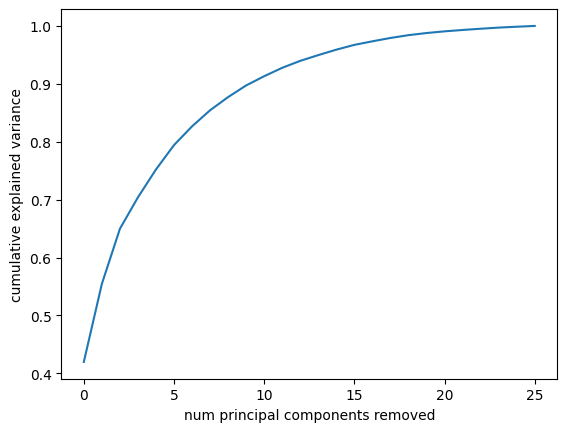

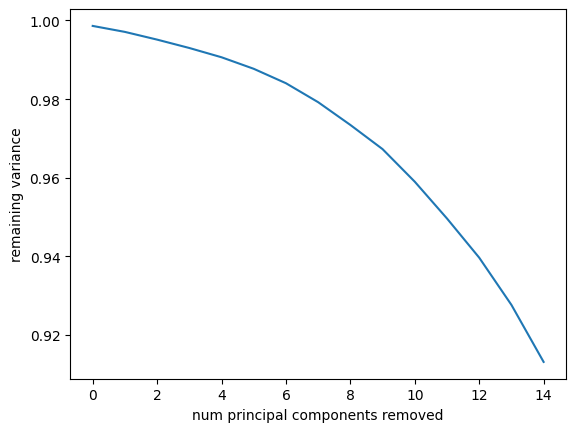

In [41]:
#p
print(pca.explained_variance_ratio_)
plt.plot(pca.explained_variance_ratio_.cumsum())
plt.ylabel('cumulative explained variance')
plt.xlabel('num principal components removed')
plt.show()
plt.plot(1-pca.explained_variance_ratio_[::-1].cumsum()[:15])
plt.ylabel('remaining variance')
plt.xlabel('num principal components removed')
plt.show()

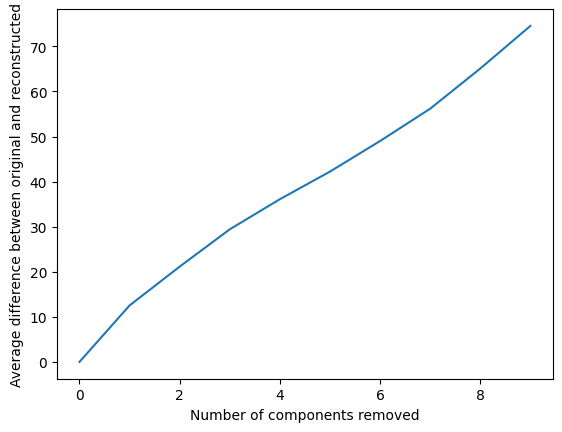

In [42]:
#remove 5 components
def remove_n_components(n):
    transformed = pca.transform(X)
    if n > 0:
        transformed[:,-n:] = 0
    #transform back to original space
    Xhat = pca.inverse_transform(transformed)
    diff = Xhat-X
    avg_diff_norm = np.mean(np.linalg.norm(diff,axis=1))
    return avg_diff_norm
diffs = [remove_n_components(i) for i in range(10)]

plt.plot(diffs)
plt.ylabel("Average difference between original and reconstructed")
plt.xlabel("Number of components removed")
plt.show()

    